In [ ]:
import torch
import torch.nn as nn
import numpy as np
import polars as pl
from path_config import PathConfig
from itertools import product
import matplotlib.pyplot as plt
import copy
paths = PathConfig()

In [2]:
signal_data = pl.read_parquet(paths._processed_measured_coverage_dir / "measured_signal_coverage.parquet")
cluster_df = pl.read_parquet(paths._processed_saha_olcum_dir / "merged_aggregated_clustered_data_dl.parquet")["Longitude", "Latitude", "cluster"].unique()
signal_data = signal_data.select(signal_data.columns).join(cluster_df, on=["Longitude", "Latitude"])

In [3]:
aggc_train_test = {
    1:[2,3,4,5,6,7,9],
    2:[0,1,4,5,6,8],
    3:[1,4,5,6,8,9,0],
    4:[1,2,3,5,7,8,9],
    5:[1,2,3,4,7,8,0],
    6:[1,2,3,8,0],
    7:[1,4,5,8,9,0],
    8:[2,3,4,5,6,7,9,0],
    9:[1,3,4,7,8,0],
    0:[2,3,5,6,7,8,9]
}

In [4]:
calculated_coverage = pl.read_parquet(paths._processed_coverage_dir/"calculated_grid_rsrp_10m_data.parquet")
columns = ["Latitude", "Longitude", ] + [col for col in calculated_coverage.columns if "RSRP_dBm_FSPL_PCI_" in col] 
calculated_coverage = calculated_coverage[columns]
calculated_coverage

Latitude,Longitude,RSRP_dBm_FSPL_PCI_30,RSRP_dBm_FSPL_PCI_40,RSRP_dBm_FSPL_PCI_59,RSRP_dBm_FSPL_PCI_48,RSRP_dBm_FSPL_PCI_68,RSRP_dBm_FSPL_PCI_76,RSRP_dBm_FSPL_PCI_3,RSRP_dBm_FSPL_PCI_13,RSRP_dBm_FSPL_PCI_23
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
41.10609,29.014558,-98.529985,-72.496481,-88.809712,-104.287636,-80.860006,-101.949363,-74.625479,-97.960171,-95.278348
41.106181,29.014561,-98.498291,-72.486864,-89.113114,-104.269406,-81.084744,-101.954317,-74.446858,-98.010959,-95.288175
41.106271,29.014564,-98.468526,-72.4952,-89.42372,-104.251861,-81.316312,-101.960289,-74.289338,-98.06394,-95.302612
41.105998,29.014675,-98.410285,-72.3529,-88.357695,-104.222148,-80.534257,-101.83121,-74.583606,-97.742338,-95.039578
41.106088,29.014677,-98.375711,-72.321583,-88.654907,-104.2029,-80.754332,-101.835222,-74.386692,-97.792509,-95.045006
…,…,…,…,…,…,…,…,…,…,…
41.100189,29.037717,-105.742401,-105.989233,-104.566021,-88.176435,-100.752081,-100.752081,-106.277728,-106.277728,-85.381625
41.100279,29.037719,-105.703911,-105.954089,-104.505345,-87.907109,-100.680648,-100.680648,-106.256856,-106.256856,-85.486239
41.100006,29.03783,-105.880025,-106.120044,-104.743613,-88.552276,-100.998896,-100.998896,-106.385576,-106.385576,-85.289212


In [5]:
def prepare_rsrp_data(calculated_coverage, signal_data):
    calc_coords = calculated_coverage.select(calculated_coverage.columns[:2]).to_numpy()
    calc_rsrp = calculated_coverage.select(calculated_coverage.columns[2:]).to_numpy()
    
    signal_coords = signal_data.select(signal_data.columns[:2]).to_numpy()
    signal_rsrp = signal_data.select(signal_data.columns[2:]).to_numpy()
    
    data = {
        'q': torch.FloatTensor(calc_rsrp),            
        'x': torch.FloatTensor(calc_coords[:, 1]),     
        'y': torch.FloatTensor(calc_coords[:, 0]),   
        'p': torch.FloatTensor(signal_rsrp),            
        'x_m': torch.FloatTensor(signal_coords[:, 1]),  
        'y_m': torch.FloatTensor(signal_coords[:, 0]),  
    }
    
    print("Hazırlanan veri boyutları:")
    for key, tensor in data.items():
        print(f"{key}: {tensor.shape}")
    
    return data

def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371000 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def haversine_torch(lat1, lon1, lat2, lon2):
    R = 6371000 
    lat1, lon1, lat2, lon2 = lat1 * np.pi/180, lon1 * np.pi/180, lat2 * np.pi/180, lon2 * np.pi/180
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = torch.sin(dlat / 2)**2 + torch.cos(lat1) * torch.cos(lat2) * torch.sin(dlon / 2)**2
    c = 2 * torch.arcsin(torch.sqrt(a))
    return R * c

def predict_locations(model, p, q, GPU=False):
    if GPU:
        device = torch.device("cpu")
        
        model = model.to(device)
        p = p.to(device)
        q = q.to(device)

    model.eval()
    with torch.no_grad():
        pred_x_m = model.v_x(p).squeeze()
        pred_y_m = model.v_y(p).squeeze()
        pred_x_s = model.u_x(q).squeeze()
        pred_y_s = model.u_y(q).squeeze()
        
    return pred_x_m, pred_y_m, pred_x_s, pred_y_s

In [9]:
class FixedWeightRSRPModel(nn.Module):
    def __init__(self, dim=9):
        super().__init__()
        self.u_x = self._create_network(dim)
        self.u_y = self._create_network(dim)
        self.v_x = self._create_network(dim)
        self.v_y = self._create_network(dim)
    
    def _create_network(self, dim):
        return nn.Sequential(
                            nn.Linear(dim, 1024),
                            nn.BatchNorm1d(1024),
                            nn.GELU(),
                            nn.Dropout(0.3),
                            nn.Linear(1024, 256),
                            nn.BatchNorm1d(256),
                            nn.GELU(),
                            nn.Dropout(0.2),
                            nn.Linear(256, 96), 
                            nn.BatchNorm1d(96),
                            nn.GELU(),
                            nn.Dropout(0.15),
                            nn.Linear(96, 64),
                            nn.BatchNorm1d(64),
                            nn.GELU(),   
                            nn.Dropout(0.10),
                            nn.Linear(64, 32),
                            nn.GELU(),  
                            nn.Dropout(0.1),
                            nn.Linear(32, 8),
                            nn.GELU(),
                            nn.Linear(8, 1),
                        )

    
    def forward(self, q, x, y, p, x_m, y_m, w_x=0.5, w_y=0.5, lambda1=0.00001, lambda2=0.00001, distance_weight=1.0):
        pred_x_sim = self.u_x(q).squeeze()
        pred_y_sim = self.u_y(q).squeeze()
        pred_x_meas = self.v_x(p).squeeze()
        pred_y_meas = self.v_y(p).squeeze()
        
        n_sim = len(q)
        n_meas = len(p)
        
        loss_x = (1 - w_x) * torch.sum((pred_x_sim - x) ** 2) * (n_meas / n_sim) + \
                 w_x * torch.sum((pred_x_meas - x_m) ** 2)
        loss_y = (1 - w_y) * torch.sum((pred_y_sim - y) ** 2) * (n_meas / n_sim) + \
                 w_y * torch.sum((pred_y_meas - y_m) ** 2)

        
        #distances = haversine_torch(y_m, x_m, pred_y_meas, pred_x_meas)
        #distance_loss = torch.mean(distances) veya torch.max(distances)

        reg = lambda1 * sum(p.norm() for p in self.u_x.parameters()) + \
              lambda1 * sum(p.norm() for p in self.u_y.parameters()) + \
              lambda2 * sum(p.norm() for p in self.v_x.parameters()) + \
              lambda2 * sum(p.norm() for p in self.v_y.parameters())
        
        # mesafeyi de loss a eklemek için yorumları kaldır

        total_loss = loss_x + loss_y + reg  # distance_weight * distance_loss 
        return total_loss

In [ ]:
# CPU
def train_fixed_weight_model(
    model,
    q, x, y, p, x_m, y_m,
    w_x=0.4, w_y=0.4,
    lambda1=0.001, lambda2=0.001,
    lr=0.001, steps=10000,
    patience=6000,
    distance_weight=1.0
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_loss = float('inf')
    best_state = None
    steps_since_improvement = 0
    
    for step in range(steps):
        model.train()
        optimizer.zero_grad()
        loss = model(q, x, y, p, x_m, y_m, w_x=w_x, w_y=w_y, lambda1=lambda1, lambda2=lambda2, distance_weight = distance_weight)
        
        if torch.isnan(loss):
            print(f"[{step}] Loss NaN oldu! Eğitim durduruluyor.")
            break
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Early stopping kontrolü
        if loss.item() < best_loss - 1e-6:
            best_loss = loss.item()
            best_state = copy.deepcopy(model.state_dict())
            steps_since_improvement = 0
        else:
            steps_since_improvement += 1
        
        if step % 100 == 0:
            # Evaluation metric hesapla
            model.eval()
            with torch.no_grad():
                pred_x_meas = model.v_x(p).squeeze()
                pred_y_meas = model.v_y(p).squeeze()

                pred_x_calc = model.u_x(q).squeeze()
                pred_y_calc = model.u_y(q).squeeze() 
                
                dist_meas = haversine_np(y_m.numpy(), x_m.numpy(), pred_y_meas.numpy(), pred_x_meas.numpy())
                dist_sim = haversine_np(y.numpy(), x.numpy(), pred_y_calc.numpy(), pred_x_calc.numpy())

                avg_dist_meas = np.mean(dist_meas)
                avg_dist_sim = np.mean(dist_sim)

            print(f"[{step}] Loss: {loss.item():.4f} | Best: {best_loss:.4f} | AVG Measured Distance: {avg_dist_meas:.1f}m | AVG Simulated Distance: {avg_dist_sim:.1f}m")
            
        if steps_since_improvement >= patience:
            print(f"Early stopping: {patience} adımda iyileşme olmadı.")
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"En iyi model {best_loss:.4f} loss ile geri yüklendi ve kaydedildi.")
        torch.save(model.state_dict(), "best_weighted_rsrp_model.pt")



In [ ]:
# GPU
def gpu_train_fixed_weight_model(
    model,
    q, x, y, p, x_m, y_m,
    w_x=0.4, w_y=0.4,
    lambda1=0.001, lambda2=0.001,
    lr=0.001, steps=10000,
    patience=6000,
    distance_weight=1.0
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    model = model.to(device)
    q = q.to(device)
    x = x.to(device)
    y = y.to(device)
    p = p.to(device)
    x_m = x_m.to(device)
    y_m = y_m.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=400, min_lr=0.0005)

    best_loss = float('inf')
    best_state = None
    steps_since_improvement = 0
    
    for step in range(steps):
        model.train()
        optimizer.zero_grad()
        loss = model(q, x, y, p, x_m, y_m, w_x=w_x, w_y=w_y, lambda1=lambda1, lambda2=lambda2, distance_weight = distance_weight)
        
        if torch.isnan(loss):
            print(f"[{step}] Loss NaN oldu! Eğitim durduruluyor.")
            break
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step(loss)

        # Early stopping kontrolü
        if loss.item() < best_loss - 1e-6:
            best_loss = loss.item()
            best_state = copy.deepcopy(model.state_dict())
            steps_since_improvement = 0
        else:
            steps_since_improvement += 1
        
        if step % 100 == 0:
            # Evaluation metric hesapla
            model.eval()
            with torch.no_grad():
                pred_x_meas = model.v_x(p).squeeze()
                pred_y_meas = model.v_y(p).squeeze()

                pred_x_calc = model.u_x(q).squeeze()
                pred_y_calc = model.u_y(q).squeeze() 
                
                dist_meas = haversine_np(y_m.cpu().numpy(), x_m.cpu().numpy(), pred_y_meas.cpu().numpy(), pred_x_meas.cpu().numpy())
                dist_sim = haversine_np(y.cpu().numpy(), x.cpu().numpy(), pred_y_calc.cpu().numpy(), pred_x_calc.cpu().numpy())

                avg_dist_meas = np.mean(dist_meas)
                avg_dist_sim = np.mean(dist_sim)

            print(f"[{step}] Loss: {loss.item():.4f} | Best: {best_loss:.4f} | AVG Measured Distance: {avg_dist_meas:.1f}m | AVG Simulated Distance: {avg_dist_sim:.1f}m | lr: {optimizer.param_groups[0]['lr']:.4f}")
            
        if steps_since_improvement >= patience:
            print(f"Early stopping: {patience} adımda iyileşme olmadı.")
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"En iyi model {best_loss:.4f} loss ile geri yüklendi ve kaydedildi.")
        torch.save(model.state_dict(), "best_weighted_rsrp_model.pt")

In [ ]:
# GPU
def gpu_train_fixed_weight_model(
    model,
    q, x, y, p, x_m, y_m,
    w_x=0.4, w_y=0.4,
    lambda1=0.001, lambda2=0.001,
    lr=0.001, steps=10000,
    patience=6000,
    distance_weight=1.0
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    model = model.to(device)
    q = q.to(device)
    x = x.to(device)
    y = y.to(device)
    p = p.to(device)
    x_m = x_m.to(device)
    y_m = y_m.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=400, min_lr=0.0005)

    best_loss = float('inf')
    best_state = None
    steps_since_improvement = 0
    
    for step in range(steps):
        model.train()
        optimizer.zero_grad()
        loss = model(q, x, y, p, x_m, y_m, w_x=w_x, w_y=w_y, lambda1=lambda1, lambda2=lambda2, distance_weight = distance_weight)
        
        if torch.isnan(loss):
            print(f"[{step}] Loss NaN oldu! Eğitim durduruluyor.")
            break
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step(loss)

        # Early stopping kontrolü
        if loss.item() < best_loss - 1e-6:
            best_loss = loss.item()
            best_state = copy.deepcopy(model.state_dict())
            steps_since_improvement = 0
        else:
            steps_since_improvement += 1
        
        if step % 100 == 0:
            # Evaluation metric hesapla
            model.eval()
            with torch.no_grad():
                pred_x_meas = model.v_x(p).squeeze()
                pred_y_meas = model.v_y(p).squeeze()

                pred_x_calc = model.u_x(q).squeeze()
                pred_y_calc = model.u_y(q).squeeze() 
                
                dist_meas = haversine_np(y_m.cpu().numpy(), x_m.cpu().numpy(), pred_y_meas.cpu().numpy(), pred_x_meas.cpu().numpy())
                dist_sim = haversine_np(y.cpu().numpy(), x.cpu().numpy(), pred_y_calc.cpu().numpy(), pred_x_calc.cpu().numpy())

                avg_dist_meas = np.mean(dist_meas)
                avg_dist_sim = np.mean(dist_sim)

            print(f"[{step}] Loss: {loss.item():.4f} | Best: {best_loss:.4f} | AVG Measured Distance: {avg_dist_meas:.1f}m | AVG Simulated Distance: {avg_dist_sim:.1f}m | lr: {optimizer.param_groups[0]['lr']:.4f}")
            
        if steps_since_improvement >= patience:
            print(f"Early stopping: {patience} adımda iyileşme olmadı.")
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"En iyi model {best_loss:.4f} loss ile geri yüklendi ve kaydedildi.")
        torch.save(model.state_dict(), "best_weighted_rsrp_model.pt")
                
data = prepare_rsrp_data(calculated_coverage, signal_data)
q = data['q']
x = data['x']
y = data['y']
p = data['p']
x_m = data['x_m']
y_m = data['y_m']

model = FixedWeightRSRPModel(dim=9)
gpu_train_fixed_weight_model(model, q, x, y, p, x_m, y_m, w_x=0.5, w_y=0.5, lr=0.01, steps=10000, patience=1000)

Hazırlanan veri boyutları:
q: torch.Size([17105, 9])
x: torch.Size([17105])
y: torch.Size([17105])
p: torch.Size([3175, 9])
x_m: torch.Size([3175])
y_m: torch.Size([3175])
Using device: cuda
[0] Loss: 8016972.0000 | Best: 8016972.0000 | AVG Measured Distance: 9446320.0m | AVG Simulated Distance: 9649765.0m | lr: 0.1000
[100] Loss: 232545.4062 | Best: 93870.2266 | AVG Measured Distance: 1095592.1m | AVG Simulated Distance: 496161.9m | lr: 0.1000
[200] Loss: 60823.6914 | Best: 60823.6914 | AVG Measured Distance: 189807.3m | AVG Simulated Distance: 208458.5m | lr: 0.1000
[300] Loss: 27315.3164 | Best: 26886.2363 | AVG Measured Distance: 51713.1m | AVG Simulated Distance: 261046.9m | lr: 0.1000
[400] Loss: 6061.9507 | Best: 4935.1997 | AVG Measured Distance: 38636.5m | AVG Simulated Distance: 173467.0m | lr: 0.1000
[500] Loss: 287.0645 | Best: 96.1117 | AVG Measured Distance: 121265.4m | AVG Simulated Distance: 48099.0m | lr: 0.1000
[600] Loss: 507.2714 | Best: 28.8544 | AVG Measured Dista

In [ ]:
class FixedWeightRSRPModel(nn.Module):
    def __init__(self, dim=9):
        super().__init__()
        self.u_x = self._create_network(dim)
        self.u_y = self._create_network(dim)
        self.v_x = self._create_network(dim)
        self.v_y = self._create_network(dim)
    
    def _create_network(self, dim):
        return nn.Sequential(
                            nn.Linear(dim, 1024),
                            nn.BatchNorm1d(1024),
                            nn.GELU(),
                            nn.Dropout(0.3),
                            nn.Linear(1024, 256),
                            nn.BatchNorm1d(256),
                            nn.GELU(),
                            nn.Dropout(0.2),
                            nn.Linear(256, 96), 
                            nn.BatchNorm1d(96),
                            nn.GELU(),
                            nn.Dropout(0.15),
                            nn.Linear(96, 64),
                            nn.BatchNorm1d(64),
                            nn.GELU(),   
                            nn.Dropout(0.10),
                            nn.Linear(64, 32),
                            nn.GELU(),  
                            nn.Dropout(0.1),
                            nn.Linear(32, 8),
                            nn.GELU(),
                            nn.Linear(8, 1),
                        )

    
    def forward(self, q, x, y, p, x_m, y_m, w_x=0.5, w_y=0.5, lambda1=0.00001, lambda2=0.00001, distance_weight=1.0):
        pred_x_sim = self.u_x(q).squeeze()
        pred_y_sim = self.u_y(q).squeeze()
        pred_x_meas = self.v_x(p).squeeze()
        pred_y_meas = self.v_y(p).squeeze()
        
        n_sim = len(q)
        n_meas = len(p)
        
        loss_x = (1 - w_x) * torch.sum((pred_x_sim - x) ** 2) * (n_meas / n_sim) + \
                 w_x * torch.sum((pred_x_meas - x_m) ** 2)
        loss_y = (1 - w_y) * torch.sum((pred_y_sim - y) ** 2) * (n_meas / n_sim) + \
                 w_y * torch.sum((pred_y_meas - y_m) ** 2)

        
        #distances = haversine_torch(y_m, x_m, pred_y_meas, pred_x_meas)
        #distance_loss = torch.mean(distances) veya torch.max(distances)

        reg = lambda1 * sum(p.norm() for p in self.u_x.parameters()) + \
              lambda1 * sum(p.norm() for p in self.u_y.parameters()) + \
              lambda2 * sum(p.norm() for p in self.v_x.parameters()) + \
              lambda2 * sum(p.norm() for p in self.v_y.parameters())
        
        # mesafeyi de loss a eklemek için yorumları kaldır

        total_loss = loss_x + loss_y + reg  # distance_weight * distance_loss 
        return total_loss

# GPU
def gpu_train_fixed_weight_model(
    model,
    q, x, y, p, x_m, y_m,
    w_x=0.4, w_y=0.4,
    lambda1=0.001, lambda2=0.001,
    lr=0.001, steps=10000,
    patience=6000,
    distance_weight=1.0
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    model = model.to(device)
    q = q.to(device)
    x = x.to(device)
    y = y.to(device)
    p = p.to(device)
    x_m = x_m.to(device)
    y_m = y_m.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=400, min_lr=0.0005)

    best_loss = float('inf')
    best_state = None
    steps_since_improvement = 0
    
    for step in range(steps):
        model.train()
        optimizer.zero_grad()
        loss = model(q, x, y, p, x_m, y_m, w_x=w_x, w_y=w_y, lambda1=lambda1, lambda2=lambda2, distance_weight = distance_weight)
        
        if torch.isnan(loss):
            print(f"[{step}] Loss NaN oldu! Eğitim durduruluyor.")
            break
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step(loss)

        # Early stopping kontrolü
        if loss.item() < best_loss - 1e-6:
            best_loss = loss.item()
            best_state = copy.deepcopy(model.state_dict())
            steps_since_improvement = 0
        else:
            steps_since_improvement += 1
        
        if step % 100 == 0:
            # Evaluation metric hesapla
            model.eval()
            with torch.no_grad():
                pred_x_meas = model.v_x(p).squeeze()
                pred_y_meas = model.v_y(p).squeeze()

                pred_x_calc = model.u_x(q).squeeze()
                pred_y_calc = model.u_y(q).squeeze() 
                
                dist_meas = haversine_np(y_m.cpu().numpy(), x_m.cpu().numpy(), pred_y_meas.cpu().numpy(), pred_x_meas.cpu().numpy())
                dist_sim = haversine_np(y.cpu().numpy(), x.cpu().numpy(), pred_y_calc.cpu().numpy(), pred_x_calc.cpu().numpy())

                avg_dist_meas = np.mean(dist_meas)
                avg_dist_sim = np.mean(dist_sim)

            print(f"[{step}] Loss: {loss.item():.4f} | Best: {best_loss:.4f} | AVG Measured Distance: {avg_dist_meas:.1f}m | AVG Simulated Distance: {avg_dist_sim:.1f}m | lr: {optimizer.param_groups[0]['lr']:.4f}")
            
        if steps_since_improvement >= patience:
            print(f"Early stopping: {patience} adımda iyileşme olmadı.")
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"En iyi model {best_loss:.4f} loss ile geri yüklendi ve kaydedildi.")
        torch.save(model.state_dict(), "best_weighted_rsrp_model.pt")

    return best_loss

def hyperparameter_tuning_with_test(train_data, test_data, param_grid, dim=9):

    print("Hyperparameter tuning başlatılıyor...")
    
    # Parametre kombinasyonlarını oluştur
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    param_combinations = list(product(*param_values))
    
    print(f"Toplam {len(param_combinations)} parametre kombinasyonu test edilecek.")
    
    best_params = None
    best_test_score = float('inf')
    results = []
    
    for i, param_values in enumerate(param_combinations):
        # Parametre dict'i oluştur
        params = dict(zip(param_names, param_values))
        
        print(f"\n{'='*50}")
        print(f"Kombinasyon {i+1}/{len(param_combinations)}")
        print(f"Parametreler: {params}")
        
        try:
            # Model oluştur ve train data ile eğit
            model = FixedWeightRSRPModel(dim=dim)
            train_loss = gpu_train_fixed_weight_model(
                model, 
                train_data['q'], train_data['x'], train_data['y'], 
                train_data['p'], train_data['x_m'], train_data['y_m'],
                **params
            )
            
            # Test setinde değerlendir
            test_metrics = evaluate_on_test_set(model, test_data, params)
            test_loss = test_metrics['test_loss']
            
            # Sonuçları kaydet
            result = {
                'params': params.copy(),
                'train_loss': train_loss,
                'test_loss': test_loss,
                'test_metrics': test_metrics
            }
            results.append(result)
            
            print(f"Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")
            print(f"Test Avg Distance - Measured: {test_metrics['avg_measured_distance']:.1f}m, Simulated: {test_metrics['avg_simulated_distance']:.1f}m")
            
            # En iyi sonucu güncelle
            if test_loss < best_test_score:
                best_test_score = test_loss
                best_params = params.copy()
                print(f"YENİ EN İYİ! Test Loss: {test_loss:.4f}")
            
            # Memory temizle
            del model
            torch.cuda.empty_cache()
            
        except Exception as e:
            print(f"Hata oluştu: {e}")
            continue
    
    print(f"\n{'='*60}")
    print("HYPERPARAMETER TUNING TAMAMLANDI!")
    print(f"En iyi parametreler: {best_params}")
    print(f"En iyi test skoru: {best_test_score:.4f}")
    
    return best_params, best_test_score, results

def evaluate_on_test_set(model, test_data, params):
    """
    Test setinde model performansını değerlendir
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Test verisini device'a taşı
    q_test = test_data['q'].to(device)
    x_test = test_data['x'].to(device)
    y_test = test_data['y'].to(device)
    p_test = test_data['p'].to(device)
    x_m_test = test_data['x_m'].to(device)
    y_m_test = test_data['y_m'].to(device)
    
    model.eval()
    with torch.no_grad():
        # Test loss hesapla
        test_loss = model(q_test, x_test, y_test, p_test, x_m_test, y_m_test,
                         w_x=params['w_x'], w_y=params['w_y'],
                         lambda1=params['lambda1'], lambda2=params['lambda2'],
                         distance_weight=params['distance_weight'])
        
        # Prediction'ları al
        pred_x_meas = model.v_x(p_test).squeeze()
        pred_y_meas = model.v_y(p_test).squeeze()
        pred_x_calc = model.u_x(q_test).squeeze()
        pred_y_calc = model.u_y(q_test).squeeze()
        
        # Distance metriklerini hesapla
        dist_meas = haversine_np(y_m_test.cpu().numpy(), x_m_test.cpu().numpy(), 
                               pred_y_meas.cpu().numpy(), pred_x_meas.cpu().numpy())
        dist_sim = haversine_np(y_test.cpu().numpy(), x_test.cpu().numpy(), 
                              pred_y_calc.cpu().numpy(), pred_x_calc.cpu().numpy())
        
        # Metrikleri hesapla
        test_metrics = {
            'test_loss': test_loss.item(),
            'avg_measured_distance': np.mean(dist_meas),
            'avg_simulated_distance': np.mean(dist_sim),
            'max_measured_distance': np.max(dist_meas),
            'max_simulated_distance': np.max(dist_sim),
            'std_measured_distance': np.std(dist_meas),
            'std_simulated_distance': np.std(dist_sim)
        }
    
    return test_metrics


for i in aggc_train_test:
    print(f"\n{'='*80}")
    print(f"CLUSTER {i} - TRAIN/TEST SPLIT")
    print(f"{'='*80}")
    
    # Polars syntax kullan
    train = signal_data.filter(pl.col("cluster").is_in(aggc_train_test[i]))
    test = signal_data.filter(pl.col("cluster") == i)
    train, test = train.drop("cluster"), test.drop("cluster")
    
    print(f"Train size: {len(train)}, Test size: {len(test)}")
    
    train_val_data = prepare_rsrp_data(calculated_coverage, train)
    test_data = prepare_rsrp_data(calculated_coverage, test)

    param_grid = {
        'w_x': [0.4, 0.6],
        'w_y': [0.4, 0.6],
        'lambda1': [0.0001],
        'lambda2': [0.0001],
        'lr': [0.01],
        'steps': [10000],
        'patience': [1000],
        'distance_weight': [1]
    }

    print(f"\n{'='*60}")
    print("1. HYPERPARAMETER TUNING (Test setine dayalı)")
    best_params, best_test_score, all_results = hyperparameter_tuning_with_test(
        train_val_data, test_data, param_grid, dim=9
    )
    
    print(f"\n{'='*60}")
    print("2. EN İYİ PARAMETRELERLE FİNAL MODEL EĞİTİMİ")
    final_model = FixedWeightRSRPModel(dim=9)
    final_train_loss = gpu_train_fixed_weight_model(
        final_model,
        train_val_data['q'], train_val_data['x'], train_val_data['y'], 
        train_val_data['p'], train_val_data['x_m'], train_val_data['y_m'],
        **best_params
    )

    print(f"\n{'='*60}")
    print("3. FİNAL TEST SONUÇLARI")
    final_test_metrics = evaluate_on_test_set(final_model, test_data, best_params)
    
    print(f"En iyi parametreler: {best_params}")
    print(f"Final Train Loss: {final_train_loss:.4f}")
    print(f"CLUSTER {i} FİNAL TEST SONUÇLARI:")
    print(f"  Test Loss: {final_test_metrics['test_loss']:.4f}")
    print(f"  Measured Distance - Avg: {final_test_metrics['avg_measured_distance']:.1f}m, Max: {final_test_metrics['max_measured_distance']:.1f}m, Std: {final_test_metrics['std_measured_distance']:.1f}m")
    print(f"  Simulated Distance - Avg: {final_test_metrics['avg_simulated_distance']:.1f}m, Max: {final_test_metrics['max_simulated_distance']:.1f}m, Std: {final_test_metrics['std_simulated_distance']:.1f}m")
    
    torch.save(final_model.state_dict(), f"best_model_cluster_{i}.pt")
    print(f"Model kaydedildi: best_model_cluster_{i}.pt")


CLUSTER 1 - TRAIN/TEST SPLIT
Train size: 2404, Test size: 162
Hazırlanan veri boyutları:
q: torch.Size([17105, 9])
x: torch.Size([17105])
y: torch.Size([17105])
p: torch.Size([2404, 9])
x_m: torch.Size([2404])
y_m: torch.Size([2404])
Hazırlanan veri boyutları:
q: torch.Size([17105, 9])
x: torch.Size([17105])
y: torch.Size([17105])
p: torch.Size([162, 9])
x_m: torch.Size([162])
y_m: torch.Size([162])

1. HYPERPARAMETER TUNING (Test setine dayalı)
Hyperparameter tuning başlatılıyor...
Toplam 4 parametre kombinasyonu test edilecek.

Kombinasyon 1/4
Parametreler: {'w_x': 0.4, 'w_y': 0.4, 'lambda1': 0.0001, 'lambda2': 0.0001, 'lr': 0.01, 'steps': 10000, 'patience': 1000, 'distance_weight': 1}
Using device: cuda
[0] Loss: 6081908.5000 | Best: 6081908.5000 | AVG Measured Distance: 5374724.5m | AVG Simulated Distance: 5147267.8m | lr: 0.0100
[100] Loss: 53029.5156 | Best: 50088.9688 | AVG Measured Distance: 87764.9m | AVG Simulated Distance: 135092.7m | lr: 0.0100
[200] Loss: 35866.3555 | Bes

KeyboardInterrupt: 

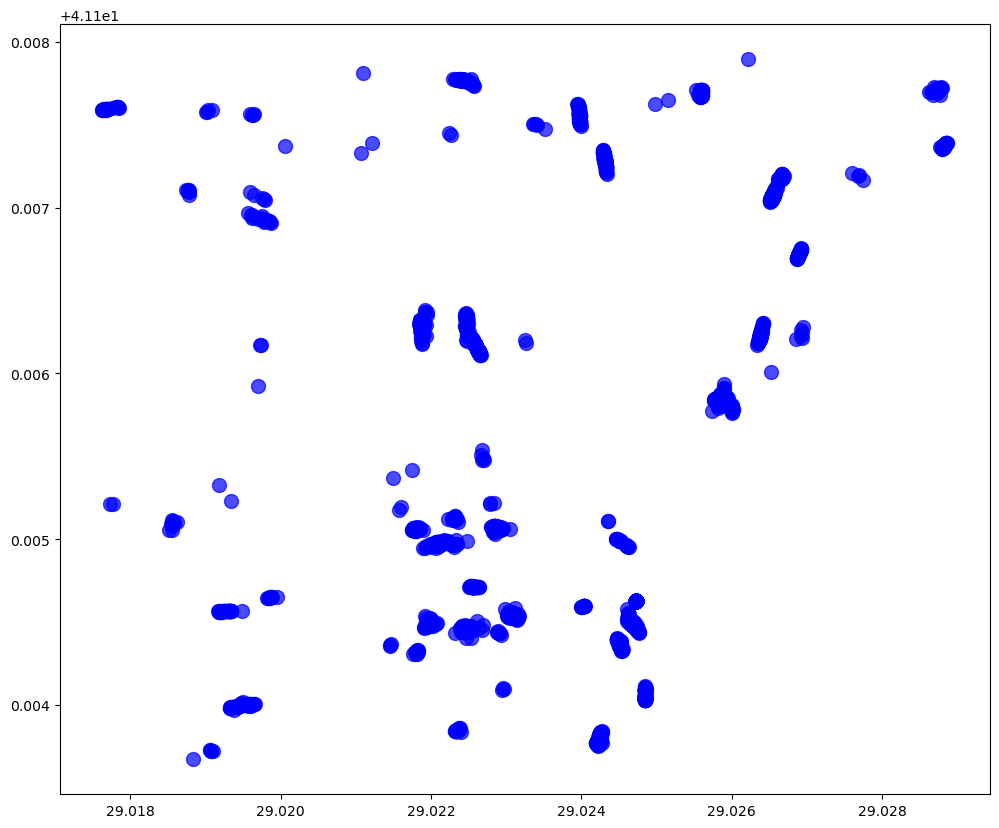

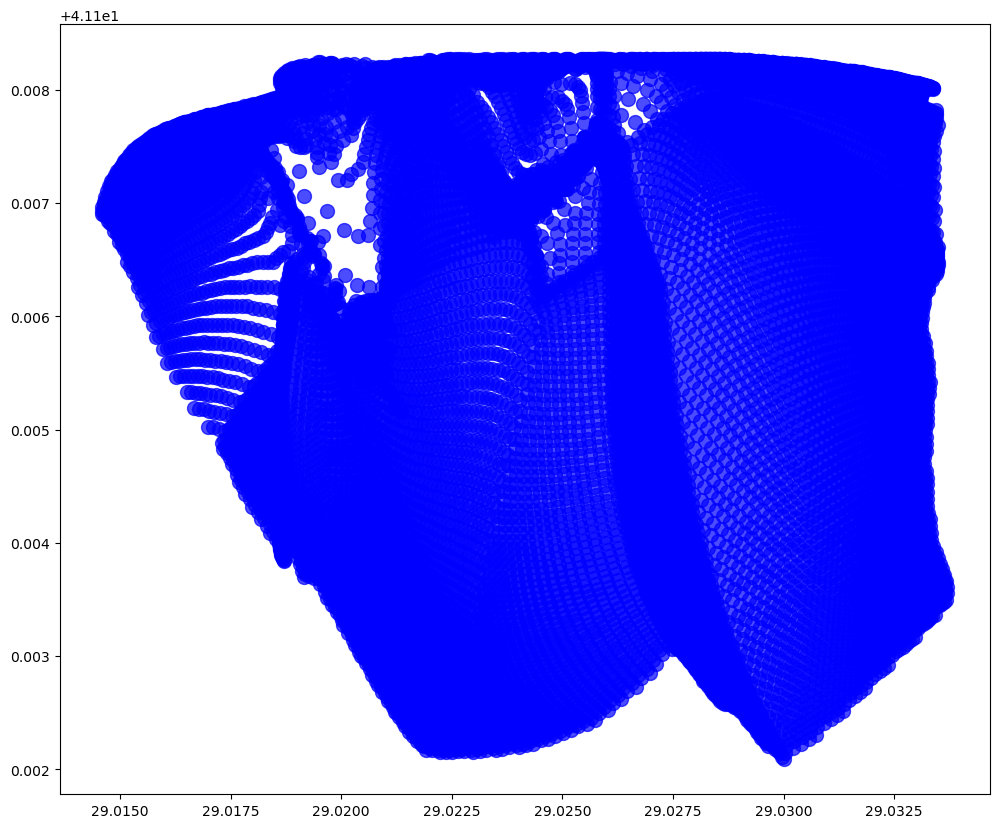

In [ ]:
pred_x_m, pred_y_m, pred_x_s, pred_y_s = predict_locations(model, p, q, GPU=True)

distances_meas = haversine_np(y_m.cpu().numpy(), x_m.cpu().numpy(), 
                             pred_y_m.numpy(), pred_x_m.numpy())
distances_sim = haversine_np(y.cpu().numpy(), x.cpu().numpy(), 
                            pred_y_s.numpy(), pred_x_s.numpy())

print(f"Average measured distance: {np.mean(distances_meas):.1f}m")
print(f"Average simulated distance: {np.mean(distances_sim):.1f}m")

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(1, 1, 1)

sc = ax.scatter(
    pred_x_m,
    pred_y_m,
    c="blue",
    s=100,
    alpha=0.7
)

plt.show()

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(1, 1, 1)

sc = ax.scatter(
    pred_x_s,
    pred_y_s,
    c="blue",
    s=100,
    alpha=0.7
)

plt.show()